# Лекция 4. Сортировки


- Сортировка пузырьком
- Сортировка вставками
- Сортировка слиянием
- Подсчет количества инверсий




Обычно, время сортировки О(n * log(n)).

## Сортировка пузырьком

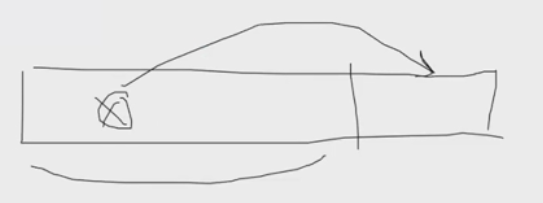

Асимптотика - n^2

## Сортировка вставками

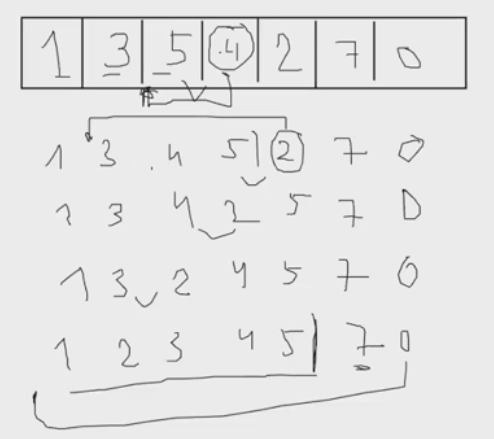

Асимптотика:
- снизу O(n)
- сверху O(n^2)

Меньше 20 элементов - используем.

In [20]:
import random

arr = [random.randint(0, 10) for i in range(15)]

print(*arr)

n = len(arr)
for i in range(1, n):
  k = i
  while k > 1 and arr[k] < arr[k - 1]:
    arr[k], arr[k - 1] = arr[k - 1], arr[k]
    k -= 1

print(*arr)


0 3 7 1 8 10 9 3 7 0 3 10 2 6 1
0 0 1 1 2 3 3 3 6 7 7 8 9 10 10


## Сортировка слиянием

Представим, что у нас есть два отсортированных массива: [1, 4, 7, 9] и [2, 3, 5, 6, 8]. Возьмем новый массив и заведем два указателя, сольем элементы двух массивов в один:

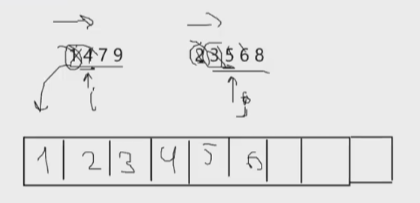

```
# if i == len(a):
```

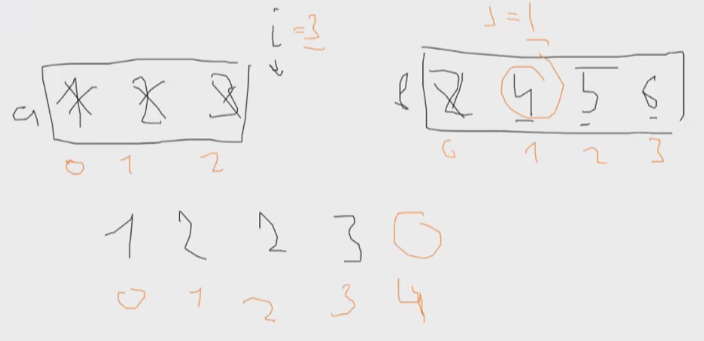

In [14]:
a = [1, 4, 7, 9]
b = [2, 3, 5, 6, 8]

def merge(a: list[int], b: list[int]) -> list[int]:
  c = [0] * (len(a) + len(b))
  i = j = 0
  while i < len(a) or j < len(b):
    if i == len(a):
      c[i + j] = b[j]
      j += 1
    elif j == len(b):
      c[i + j] = a[i]
      i += 1
    elif a[i] > b[j]:
      c[i + j] = b[j]
      j += 1
    else:
      c[i + j] = a[i]
      i += 1
  return c

print(*merge(a, b))

1 2 3 4 5 6 7 8 9


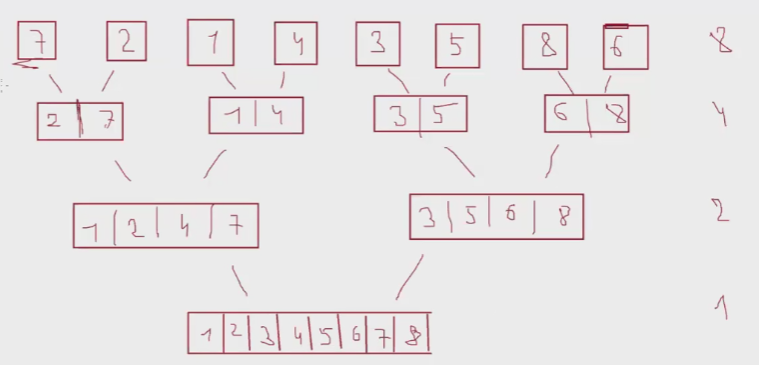

Асимптотика -  O(n * log(n)).


In [22]:
def merge(a: list[int], b: list[int]) -> list[int]:
  c = [0] * (len(a) + len(b))
  i = j = 0
  while i < len(a) or j < len(b):
    if i == len(a):
      c[i + j] = b[j]
      j += 1
    elif j == len(b):
      c[i + j] = a[i]
      i += 1
    elif a[i] > b[j]:
      c[i + j] = b[j]
      j += 1
    else:
      c[i + j] = a[i]
      i += 1
  return c

def merge_sort(arr:list[int]) -> list[int]:
  if len(arr) < 2:
    return arr
  mid = len(arr) // 2
  return merge(merge_sort(arr[:mid]), merge_sort(arr[mid:]))

print(merge_sort([9, 8, 6, 5, 4, 3, 2, 2, 2, 1]))


[1, 2, 2, 2, 3, 4, 5, 6, 8, 9]


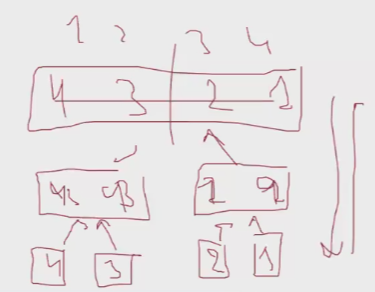


Плюсы: работает за O(n * log(n)).

Минусы: создается огромное количество массивов.

## Подсчет количества инверсий

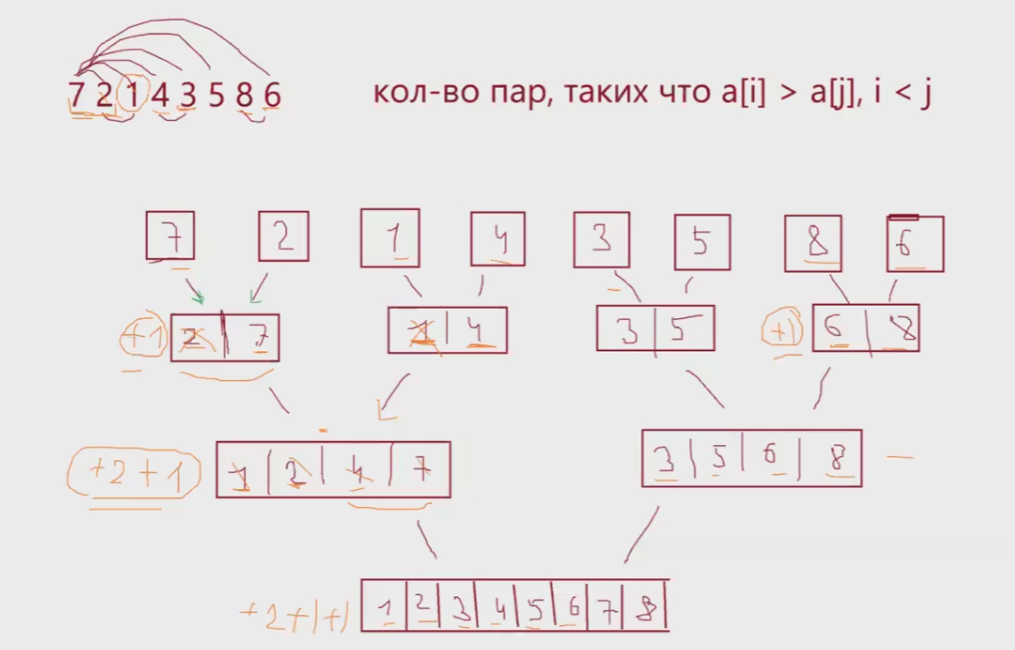




In [30]:
cnt = 0

def merge(a: list[int], b: list[int]) -> list[int]:
  global cnt
  c = [0] * (len(a) + len(b))
  i = j = 0
  while i < len(a) or j < len(b):
    if i == len(a):
      c[i + j] = b[j]
      j += 1
    elif j == len(b):
      c[i + j] = a[i]
      i += 1
    elif a[i] > b[j]:
      c[i + j] = b[j]
      cnt += len(a) - i
      j += 1
    else:
      c[i + j] = a[i]
      i += 1
  return c

def merge_sort(arr:list[int]) -> list[int]:
  if len(arr) < 2:
    return arr
  mid = len(arr) // 2
  return merge(merge_sort(arr[:mid]), merge_sort(arr[mid:]))

print(merge_sort([7, 2, 1, 4, 3, 5, 8, 6]))
print(cnt)

[1, 2, 3, 4, 5, 6, 7, 8]
9
